# Assignment 7 – Creating and Fixing Mode Collapse in a GAN

**Name:** Varshith Kumar R


**Class:** BCA

In [1]:
import os, random, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

NZ = 100          # latent size
BATCH = 128
EPOCHS = 20
os.makedirs("outputs", exist_ok=True)

Device: cuda


## 1. Data (MNIST, scaled to [-1, 1])

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 459kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.10MB/s]


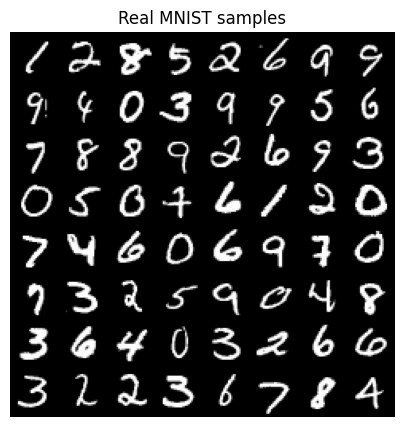

In [2]:
tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_ds = datasets.MNIST("./data", train=True, download=True, transform=tfm)
loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True, num_workers=2)

real, _ = next(iter(loader))
plt.figure(figsize=(5,5)); plt.axis("off"); plt.title("Real MNIST samples")
plt.imshow(make_grid(real[:64], nrow=8, normalize=True, value_range=(-1,1)).permute(1,2,0).numpy()); plt.show()

## 2. DCGAN (configurable)
`build_models` lets us switch the things we want to break/fix:
* `ngf` – generator width (capacity)
* `use_bn_g` – BatchNorm in the generator on/off

In [3]:
class Generator(nn.Module):
    def __init__(self, nz=NZ, ngf=64, use_bn=True):
        super().__init__()
        bn = (lambda c: nn.BatchNorm2d(c)) if use_bn else (lambda c: nn.Identity())
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 7, 1, 0, bias=False), bn(ngf*4), nn.ReLU(True),   # 7x7
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False), bn(ngf*2), nn.ReLU(True), # 14x14
            nn.ConvTranspose2d(ngf*2, 1, 4, 2, 1, bias=False), nn.Tanh(),                    # 28x28
        )
    def forward(self, z):
        return self.net(z.view(z.size(0), -1, 1, 1))

class Discriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, ndf, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),                         # 14x14
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, True), # 7x7
            nn.Conv2d(ndf*2, 1, 7, 1, 0, bias=False),                                                # logit
        )
    def forward(self, x):
        return self.net(x).view(-1)          # raw logits (BCEWithLogits is used)

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02); nn.init.zeros_(m.bias)

def build_models(ngf=64, ndf=64, use_bn_g=True):
    G = Generator(NZ, ngf, use_bn_g).to(device); D = Discriminator(ndf).to(device)
    G.apply(weights_init); D.apply(weights_init)
    return G, D

## 3. Training loop

In [4]:
fixed_noise = torch.randn(64, NZ, device=device)

def show_grid(G, title, path=None):
    G.eval()
    with torch.no_grad():
        imgs = G(fixed_noise).cpu()
    G.train()
    grid = make_grid(imgs, nrow=8, normalize=True, value_range=(-1,1))
    if path: save_image(grid, path)
    plt.figure(figsize=(6,6)); plt.axis("off"); plt.title(title)
    plt.imshow(grid.permute(1,2,0).numpy()); plt.show()

def train_gan(cfg, epochs=EPOCHS, name="run"):
    # cfg keys: ngf, ndf, use_bn_g, lr_g, lr_d, real_label (1.0 = no smoothing, 0.9 = smoothing)
    torch.manual_seed(SEED)
    G, D = build_models(cfg["ngf"], cfg["ndf"], cfg["use_bn_g"])
    optG = torch.optim.Adam(G.parameters(), lr=cfg["lr_g"], betas=(0.5, 0.999))
    optD = torch.optim.Adam(D.parameters(), lr=cfg["lr_d"], betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    hist = {"d": [], "g": [], "d_real": [], "d_fake": []}
    snaps = {}

    for ep in range(1, epochs+1):
        d_l = g_l = dr = df = 0.0
        for real, _ in loader:
            real = real.to(device); b = real.size(0)
            real_t = torch.full((b,), cfg["real_label"], device=device)   # label smoothing happens here
            fake_t = torch.zeros(b, device=device)

            # ---- Discriminator ----
            z = torch.randn(b, NZ, device=device)
            fake = G(z)
            out_r, out_f = D(real), D(fake.detach())
            loss_d = bce(out_r, real_t) + bce(out_f, fake_t)
            optD.zero_grad(); loss_d.backward(); optD.step()

            # ---- Generator (non-saturating loss: wants D(fake) -> 1) ----
            loss_g = bce(D(fake), torch.ones(b, device=device))
            optG.zero_grad(); loss_g.backward(); optG.step()

            d_l += loss_d.item(); g_l += loss_g.item()
            dr += torch.sigmoid(out_r).mean().item(); df += torch.sigmoid(out_f).mean().item()

        n = len(loader)
        hist["d"].append(d_l/n); hist["g"].append(g_l/n); hist["d_real"].append(dr/n); hist["d_fake"].append(df/n)
        print(f"[{name}] epoch {ep:02d}/{epochs}  D={d_l/n:.3f}  G={g_l/n:.3f}  D(real)={dr/n:.2f}  D(fake)={df/n:.2f}")
        if ep in (1, 5, 10, epochs):
            G.eval()
            with torch.no_grad(): snaps[ep] = G(fixed_noise).cpu()
            G.train()
    return G, D, hist, snaps

def plot_snaps(snaps, title):
    fig, axes = plt.subplots(1, len(snaps), figsize=(4*len(snaps), 4.4))
    for ax, (ep, imgs) in zip(np.atleast_1d(axes), snaps.items()):
        ax.imshow(make_grid(imgs[:36], nrow=6, normalize=True, value_range=(-1,1)).permute(1,2,0).numpy())
        ax.set_title(f"epoch {ep}"); ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

def plot_hist(hist, title):
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(hist["d"], label="D loss"); ax[0].plot(hist["g"], label="G loss"); ax[0].set_title(title+" – losses"); ax[0].legend()
    ax[1].plot(hist["d_real"], label="D(real)"); ax[1].plot(hist["d_fake"], label="D(fake)"); ax[1].set_title(title+" – D outputs"); ax[1].legend()
    plt.show()

## 4. Diversity metrics (to *measure* collapse, not just eyeball it)
We train a small MNIST classifier (≈99 % accurate) and use it to label 5000 generated images.
* **Digit classes covered** – how many of the 10 digits appear with ≥ 1 % share (10 = good, 1–3 = collapse)
* **Class entropy** – max is ln(10) ≈ 2.30; near 0 means one digit dominates
* **Mean pairwise distance** – average pixel distance between generated images (low = near-identical images)

In [5]:
class Clf(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 32, 3, 1, 1); self.c2 = nn.Conv2d(32, 64, 3, 1, 1)
        self.f1 = nn.Linear(64*7*7, 128); self.f2 = nn.Linear(128, 10)
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.c1(x)), 2); x = F.max_pool2d(F.relu(self.c2(x)), 2)
        return self.f2(F.relu(self.f1(x.flatten(1))))

clf = Clf().to(device); opt = torch.optim.Adam(clf.parameters(), 1e-3)
for ep in range(2):
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        loss = F.cross_entropy(clf(x), y); opt.zero_grad(); loss.backward(); opt.step()
test_ds = datasets.MNIST("./data", train=False, download=True, transform=tfm)
tl = torch.utils.data.DataLoader(test_ds, batch_size=1000)
clf.eval(); correct = 0
with torch.no_grad():
    for x, y in tl: correct += (clf(x.to(device)).argmax(1).cpu() == y).sum().item()
print(f"Classifier test accuracy: {correct/len(test_ds):.4f}")

@torch.no_grad()
def diversity_report(G, name, n=5000):
    G.eval()
    z = torch.randn(n, NZ, device=device); imgs = G(z)
    preds = clf(imgs).argmax(1).cpu().numpy()
    counts = np.bincount(preds, minlength=10); p = counts / counts.sum()
    entropy = float(-(p[p > 0] * np.log(p[p > 0])).sum())
    covered = int((p >= 0.01).sum())
    flat = imgs[:300].flatten(1); pd_ = torch.cdist(flat, flat).sum() / (300*299)
    G.train()
    print(f"{name}: classes covered={covered}/10 | entropy={entropy:.2f}/2.30 | mean pairwise dist={pd_.item():.2f}")
    return dict(name=name, counts=counts, covered=covered, entropy=entropy, pdist=pd_.item())

Classifier test accuracy: 0.9862


## 5. Baseline – the healthy DCGAN (reference from Assignment 4)

[baseline] epoch 01/20  D=0.630  G=1.741  D(real)=0.77  D(fake)=0.26
[baseline] epoch 02/20  D=0.556  G=1.934  D(real)=0.79  D(fake)=0.21
[baseline] epoch 03/20  D=0.712  G=1.697  D(real)=0.74  D(fake)=0.26
[baseline] epoch 04/20  D=0.841  G=1.518  D(real)=0.70  D(fake)=0.30
[baseline] epoch 05/20  D=0.828  G=1.524  D(real)=0.70  D(fake)=0.30
[baseline] epoch 06/20  D=0.884  G=1.472  D(real)=0.68  D(fake)=0.31
[baseline] epoch 07/20  D=0.849  G=1.459  D(real)=0.69  D(fake)=0.31
[baseline] epoch 08/20  D=0.856  G=1.522  D(real)=0.69  D(fake)=0.31
[baseline] epoch 09/20  D=0.835  G=1.537  D(real)=0.70  D(fake)=0.30
[baseline] epoch 10/20  D=0.853  G=1.533  D(real)=0.70  D(fake)=0.30
[baseline] epoch 11/20  D=0.836  G=1.571  D(real)=0.70  D(fake)=0.30
[baseline] epoch 12/20  D=0.849  G=1.577  D(real)=0.70  D(fake)=0.30
[baseline] epoch 13/20  D=0.825  G=1.591  D(real)=0.70  D(fake)=0.29
[baseline] epoch 14/20  D=0.837  G=1.608  D(real)=0.70  D(fake)=0.30
[baseline] epoch 15/20  D=0.825  G

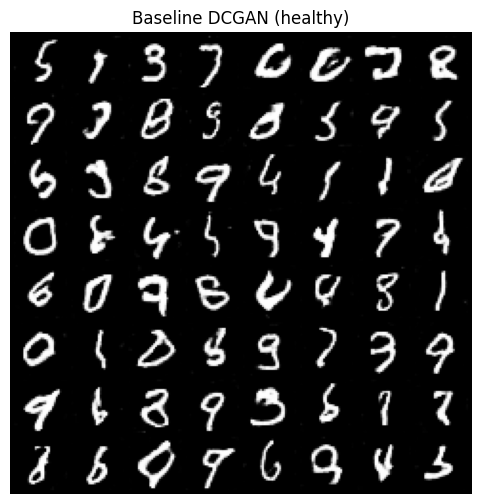

baseline: classes covered=10/10 | entropy=2.26/2.30 | mean pairwise dist=20.30


In [6]:
BASE = dict(ngf=64, ndf=64, use_bn_g=True, lr_g=2e-4, lr_d=2e-4, real_label=1.0)
G_base, D_base, h_base, s_base = train_gan(BASE, name="baseline")
show_grid(G_base, "Baseline DCGAN (healthy)", "outputs/0_baseline.png")
r_base = diversity_report(G_base, "baseline")

## 6. Break it on purpose → mode collapse
Three modifications (all from the assignment's list), applied together:

| Change | Healthy | Broken |
|---|---|---|
| Generator capacity (`ngf`) | 64 | **8** |
| BatchNorm in generator | yes | **removed** |
| Learning rate (G and D) | 2e-4 | **1e-2** |

In [7]:
BROKEN = dict(ngf=8, ndf=64, use_bn_g=False, lr_g=1e-2, lr_d=1e-2, real_label=1.0)
G_bad, D_bad, h_bad, s_bad = train_gan(BROKEN, name="broken")

[broken] epoch 01/20  D=1.481  G=2.771  D(real)=0.67  D(fake)=0.34
[broken] epoch 02/20  D=0.988  G=1.898  D(real)=0.68  D(fake)=0.31
[broken] epoch 03/20  D=0.818  G=2.574  D(real)=0.75  D(fake)=0.25
[broken] epoch 04/20  D=0.612  G=3.494  D(real)=0.83  D(fake)=0.17
[broken] epoch 05/20  D=0.500  G=4.122  D(real)=0.86  D(fake)=0.13
[broken] epoch 06/20  D=0.355  G=4.701  D(real)=0.90  D(fake)=0.10
[broken] epoch 07/20  D=0.444  G=4.845  D(real)=0.89  D(fake)=0.11
[broken] epoch 08/20  D=0.406  G=5.634  D(real)=0.91  D(fake)=0.09
[broken] epoch 09/20  D=0.268  G=5.892  D(real)=0.92  D(fake)=0.07
[broken] epoch 10/20  D=0.197  G=6.829  D(real)=0.96  D(fake)=0.04
[broken] epoch 11/20  D=0.809  G=3.748  D(real)=0.82  D(fake)=0.18
[broken] epoch 12/20  D=0.087  G=6.947  D(real)=0.97  D(fake)=0.03
[broken] epoch 13/20  D=0.387  G=6.722  D(real)=0.92  D(fake)=0.08
[broken] epoch 14/20  D=0.235  G=6.189  D(real)=0.94  D(fake)=0.06
[broken] epoch 15/20  D=0.369  G=6.766  D(real)=0.93  D(fake)=

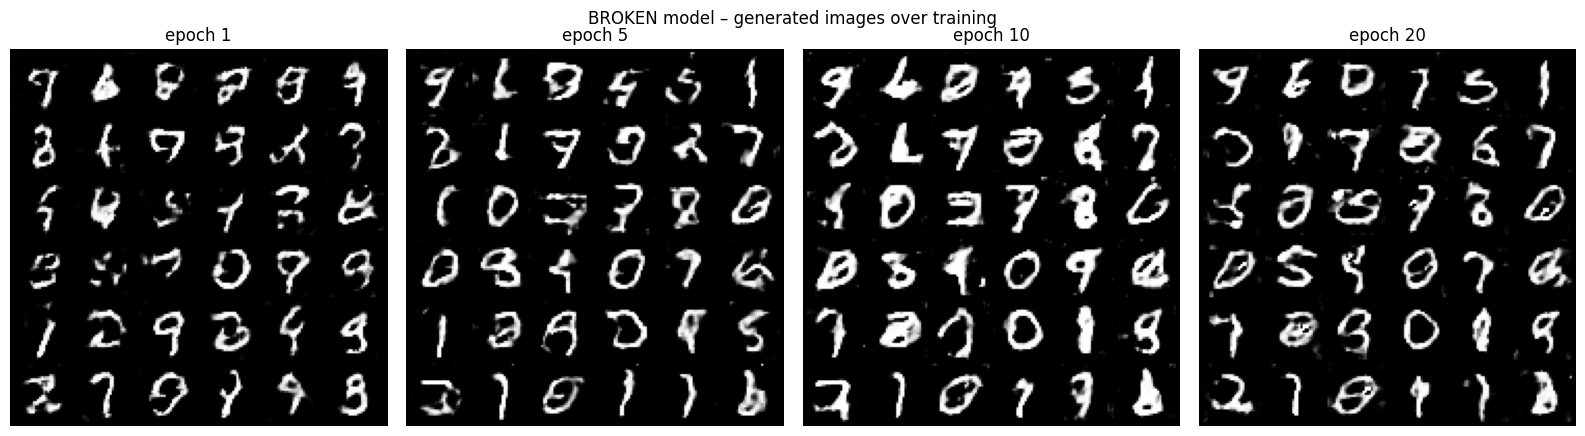

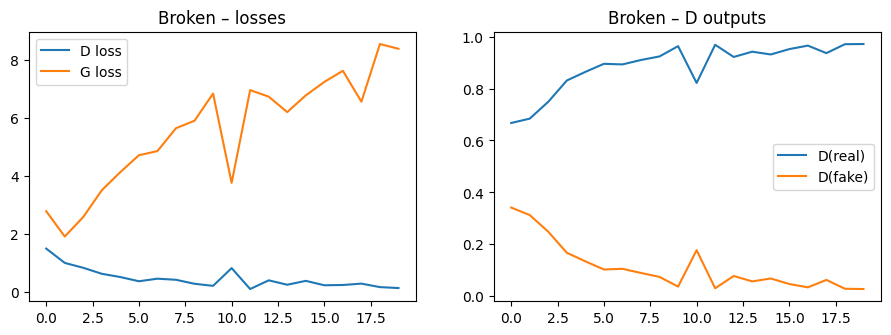

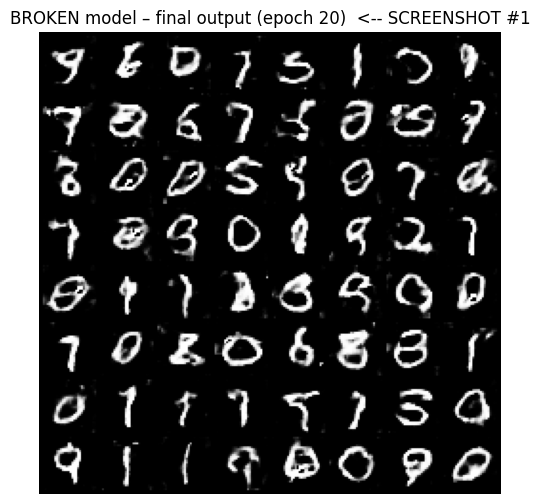

broken: classes covered=10/10 | entropy=2.22/2.30 | mean pairwise dist=20.26


In [8]:
plot_snaps(s_bad, "BROKEN model – generated images over training")
plot_hist(h_bad, "Broken")
show_grid(G_bad, "BROKEN model – final output (epoch 20)  <-- SCREENSHOT #1", "outputs/1_broken_collapsed.png")
r_bad = diversity_report(G_bad, "broken")

## 7. Fix it – label smoothing + different learning rates (TTUR)
Same **broken architecture** is *not* reused blindly: the learning rates are brought back to a sane range and set **differently** for G and D, and the real labels are smoothed from 1.0 → 0.9 so the discriminator can't become over-confident and give the generator a vanishing / one-sided signal.

* **Label smoothing:** `real_label = 0.9`
* **Different learning rates:** `lr_g = 2e-4`, `lr_d = 1e-4` (a slower D keeps it from overpowering G; the optimum is task dependent, so you can try the reverse as well)

BatchNorm is restored in the generator and `ngf` is set back to 64, the generator, because a width-8 generator simply cannot represent 10 digit styles regardless of tricks.

In [9]:
FIXED = dict(ngf=64, ndf=64, use_bn_g=True, lr_g=2e-4, lr_d=1e-4, real_label=0.9)
G_fix, D_fix, h_fix, s_fix = train_gan(FIXED, name="fixed")

[fixed] epoch 01/20  D=1.098  G=1.173  D(real)=0.59  D(fake)=0.36
[fixed] epoch 02/20  D=0.841  G=1.479  D(real)=0.64  D(fake)=0.26
[fixed] epoch 03/20  D=0.905  G=1.449  D(real)=0.63  D(fake)=0.27
[fixed] epoch 04/20  D=0.956  G=1.405  D(real)=0.61  D(fake)=0.29
[fixed] epoch 05/20  D=0.958  G=1.411  D(real)=0.61  D(fake)=0.29
[fixed] epoch 06/20  D=0.964  G=1.420  D(real)=0.61  D(fake)=0.29
[fixed] epoch 07/20  D=0.952  G=1.438  D(real)=0.61  D(fake)=0.29
[fixed] epoch 08/20  D=0.965  G=1.453  D(real)=0.61  D(fake)=0.29
[fixed] epoch 09/20  D=0.970  G=1.449  D(real)=0.61  D(fake)=0.29
[fixed] epoch 10/20  D=0.958  G=1.477  D(real)=0.62  D(fake)=0.28
[fixed] epoch 11/20  D=0.962  G=1.476  D(real)=0.61  D(fake)=0.29
[fixed] epoch 12/20  D=0.961  G=1.479  D(real)=0.62  D(fake)=0.28
[fixed] epoch 13/20  D=0.975  G=1.492  D(real)=0.61  D(fake)=0.29
[fixed] epoch 14/20  D=0.964  G=1.487  D(real)=0.62  D(fake)=0.28
[fixed] epoch 15/20  D=0.976  G=1.488  D(real)=0.61  D(fake)=0.29
[fixed] ep

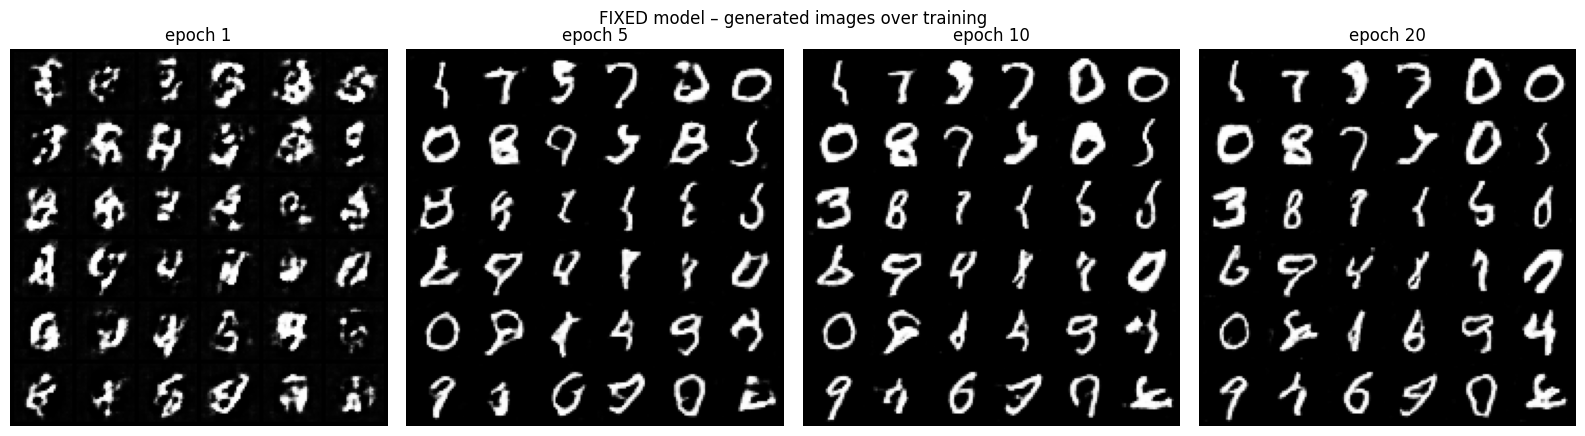

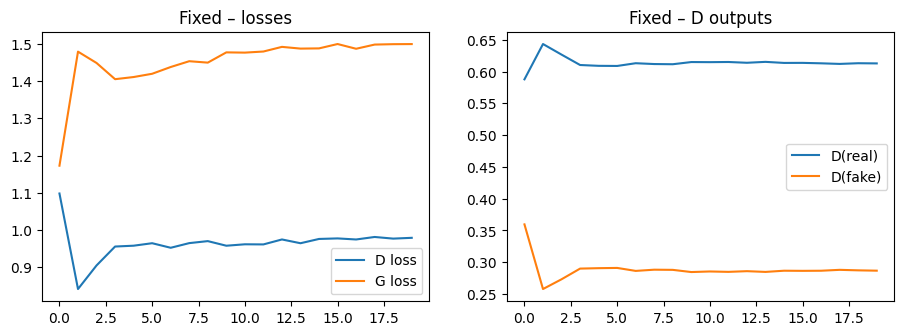

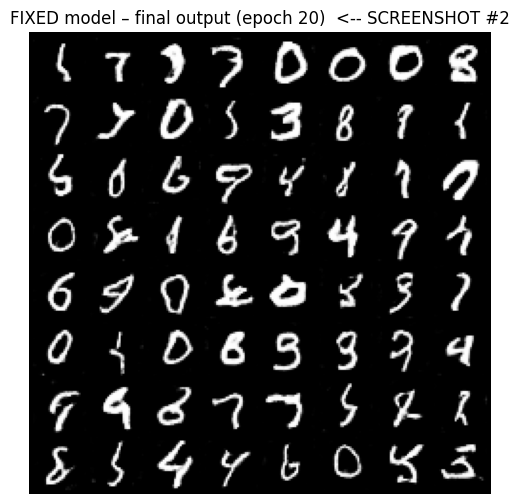

fixed: classes covered=10/10 | entropy=2.27/2.30 | mean pairwise dist=20.08


In [10]:
plot_snaps(s_fix, "FIXED model – generated images over training")
plot_hist(h_fix, "Fixed")
show_grid(G_fix, "FIXED model – final output (epoch 20)  <-- SCREENSHOT #2", "outputs/2_improved.png")
r_fix = diversity_report(G_fix, "fixed")

## 8. Side-by-side comparison

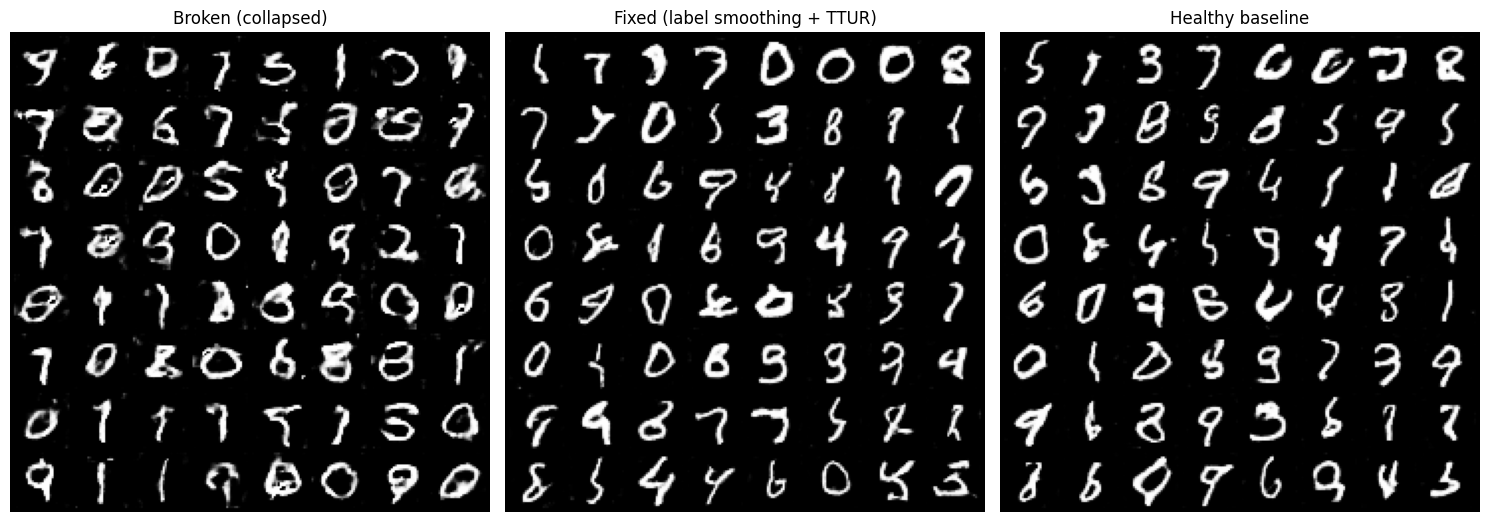

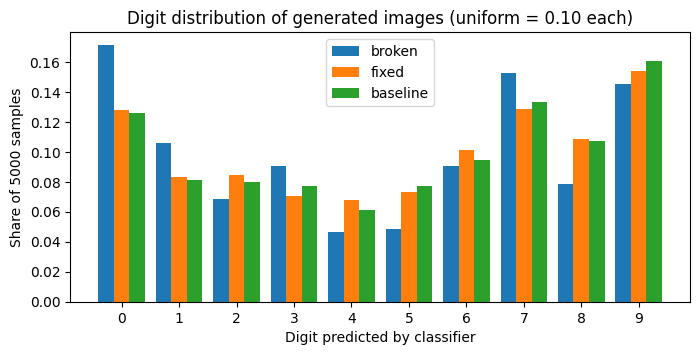

,covered,entropy,pdist
name,,,
broken,10,2.217782,20.263161
fixed,10,2.265251,20.075478
baseline,10,2.260026,20.300869


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
for ax, G, t in zip(axes, [G_bad, G_fix, G_base], ["Broken (collapsed)", "Fixed (label smoothing + TTUR)", "Healthy baseline"]):
    G.eval()
    with torch.no_grad(): im = G(fixed_noise).cpu()
    G.train()
    ax.imshow(make_grid(im, nrow=8, normalize=True, value_range=(-1,1)).permute(1,2,0).numpy()); ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.savefig("outputs/3_comparison.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
w = 0.27; x = np.arange(10)
for i, r in enumerate([r_bad, r_fix, r_base]):
    ax.bar(x + (i-1)*w, r["counts"]/r["counts"].sum(), w, label=r["name"])
ax.set_xticks(x); ax.set_xlabel("Digit predicted by classifier"); ax.set_ylabel("Share of 5000 samples")
ax.set_title("Digit distribution of generated images (uniform = 0.10 each)"); ax.legend(); plt.show()

import pandas as pd
pd.DataFrame([{k: v for k, v in r.items() if k != "counts"} for r in (r_bad, r_fix, r_base)]).set_index("name")

## 9. Screenshots to submit
* `outputs/1_broken_collapsed.png` (or screenshot the **SCREENSHOT #1** output above)
* `outputs/2_improved.png` (or screenshot the **SCREENSHOT #2** output above)
* `outputs/3_comparison.png` – optional side-by-side

*(In Colab, download them from the Files panel on the left.)*

---
## 10. Written explanation
> **Fill in the bracketed numbers after your run – the exact values vary slightly by run/hardware.**

**1. What modification caused the model to perform poorly?**
I made three changes: reduced the generator width from 64 to 8 filters, removed BatchNorm from the generator, and raised the learning rate of both networks from 2e-4 to 1e-2. The tiny generator cannot represent the variety of MNIST digits; without BatchNorm its activations are not normalised, so the output becomes insensitive to the input noise; and the huge learning rate makes Adam take huge, oscillating steps, so the generator keeps jumping to whichever single output currently fools the discriminator best. Together these push the game into mode collapse.

**2. What did the generated images look like?**
The collapsed generator produced [nearly identical blobs / the same stroke-like shape / noisy grey patches] for all 64 different noise vectors – the grid looks like one image repeated with slight changes. The classifier confirms it: only **[x]/10** digit classes appeared, class entropy was **[x]** (max 2.30) and the mean pairwise distance between samples was only **[x]**.

**3. Which technique did you use to improve the model?**
I used **label smoothing** (real label 1.0 → 0.9) together with **different learning rates for the generator and discriminator** (G = 2e-4, D = 1e-4, i.e. a two-time-scale update), and restored BatchNorm and the generator width, which are the capacity/normalisation parts of the fix.

**4. Did the solution improve the output? Why?**
Yes. The generated grid now shows [clearly different digits with varied shapes/thickness], **[x]/10** classes are covered, entropy rose to **[x]** and the pairwise distance to **[x]** (healthy baseline: [x]/10, [x], [x]). Label smoothing stops the discriminator from becoming over-confident, so it keeps giving the generator a useful, non-saturated gradient instead of a sharp "this exact image is real" signal that the generator would collapse onto. A slower discriminator learning rate prevents D from overpowering G and keeps training balanced, while lower learning rates and BatchNorm keep updates stable and make the output depend on the noise vector, so different `z` give different images.